In [1]:
# Cell 1 — Install and import everything
!pip install tensorflow pandas numpy matplotlib pillow scikit-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

print("All libraries ready!")

All libraries ready!


In [2]:
# Cell 2 — Download the dataset
!git clone https://github.com/emanhamed/Houses-dataset.git

print("Dataset downloaded!")
print()

# See what's inside
import os
files = os.listdir('Houses-dataset/Houses Dataset')
print(f"Total files: {len(files)}")
print("First 10 files:", files[:10])

Cloning into 'Houses-dataset'...
remote: Enumerating objects: 2166, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 2166 (delta 0), reused 0 (delta 0), pack-reused 2165 (from 1)
Receiving objects: 100% (2166/2166), 176.26 MiB | 44.58 MiB/s, done.
Resolving deltas: 100% (20/20), done.
Dataset downloaded!

Total files: 2141
First 10 files: ['69_frontal.jpg', '418_bathroom.jpg', '527_bedroom.jpg', '112_bathroom.jpg', '534_frontal.jpg', '53_bedroom.jpg', '364_frontal.jpg', '457_bedroom.jpg', '58_frontal.jpg', '389_kitchen.jpg']


In [3]:
# Cell 3 — Load the tabular data (prices + house info)
# This dataset stores tabular data in a separate text file
tabular_path = 'Houses-dataset/Houses Dataset/HousesInfo.txt'

# Columns based on the dataset's documentation
columns = ['bedrooms', 'bathrooms', 'area', 'zipcode', 'price']
df = pd.read_csv(tabular_path, sep=' ', header=None, names=columns)

print("Shape:", df.shape)
print()
df.head()

Shape: (535, 5)



,bedrooms,bathrooms,area,zipcode,price
0,4,4.0,4053,85255,869500
1,4,3.0,3343,36372,865200
2,3,4.0,3923,85266,889000
3,5,5.0,4022,85262,910000
4,3,4.0,4116,85266,971226


Original image size: (720, 480)


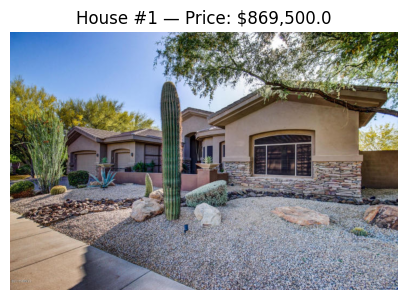

In [4]:
# Cell 4 — Load and view a sample house image
image_folder = 'Houses-dataset/Houses Dataset'

# Let's look at house #1's frontal image
sample_image_path = f'{image_folder}/1_frontal.jpg'
sample_image = Image.open(sample_image_path)

print("Original image size:", sample_image.size)

plt.figure(figsize=(5,5))
plt.imshow(sample_image)
plt.title(f"House #1 — Price: ${df.iloc[0]['price']:,}")
plt.axis('off')
plt.show()

Processed image shape: (224, 224, 3)
Pixel value range: 0.0 to 1.0


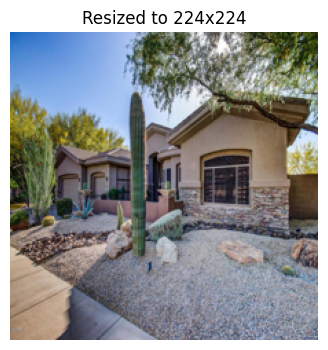

In [5]:
# Cell 5 — Load and resize all frontal images
IMG_SIZE = 224  # standard size most CNNs expect

def load_and_preprocess_image(house_id):
    img_path = f'{image_folder}/{house_id}_frontal.jpg'
    img = Image.open(img_path)
    img = img.resize((IMG_SIZE, IMG_SIZE))   # resize to 224x224
    img_array = np.array(img) / 255.0         # convert to numbers, scale 0-1
    return img_array

# Test it on house #1
test_img = load_and_preprocess_image(1)
print("Processed image shape:", test_img.shape)
print("Pixel value range:", test_img.min(), "to", test_img.max())

plt.figure(figsize=(4,4))
plt.imshow(test_img)
plt.title("Resized to 224x224")
plt.axis('off')
plt.show()

In [6]:
# Cell 6 — Load all images and match them with tabular data
images = []
valid_indices = []

for idx, row in df.iterrows():
    house_id = idx + 1   # house IDs start from 1, not 0
    img_path = f'{image_folder}/{house_id}_frontal.jpg'

    if os.path.exists(img_path):
        img_array = load_and_preprocess_image(house_id)
        images.append(img_array)
        valid_indices.append(idx)

images = np.array(images)

# Keep only the tabular rows that have a matching image
df_matched = df.iloc[valid_indices].reset_index(drop=True)

print("Total images loaded:", images.shape)
print("Matching tabular rows:", df_matched.shape)

Total images loaded: (535, 224, 224, 3)
Matching tabular rows: (535, 5)


In [7]:
# Cell 7 — Prepare tabular features
from sklearn.preprocessing import StandardScaler

# Features: bedrooms, bathrooms, area (we'll skip zipcode for simplicity)
tabular_features = df_matched[['bedrooms', 'bathrooms', 'area']].values
prices = df_matched['price'].values

# Scale tabular features (same as Task 2!)
scaler = StandardScaler()
tabular_scaled = scaler.fit_transform(tabular_features)

print("Tabular features shape:", tabular_scaled.shape)
print()
print("Before scaling (first house):", tabular_features[0])
print("After scaling (first house):", tabular_scaled[0])
print()
print("Price range: ${:,.0f} to ${:,.0f}".format(prices.min(), prices.max()))

Tabular features shape: (535, 3)

Before scaling (first house): [4.000e+00 4.000e+00 4.053e+03]
After scaling (first house): [0.53663907 1.34290707 1.37982571]

Price range: $22,000 to $5,858,000


In [8]:
# Cell 8 — Split data into train and test sets
from sklearn.model_selection import train_test_split

# Split everything together so houses stay matched correctly
X_img_train, X_img_test, X_tab_train, X_tab_test, y_train, y_test = train_test_split(
    images, tabular_scaled, prices,
    test_size=0.2,
    random_state=42
)

print("Training images:", X_img_train.shape)
print("Testing images:", X_img_test.shape)
print("Training tabular:", X_tab_train.shape)
print("Testing tabular:", X_tab_test.shape)
print("Training prices:", y_train.shape)
print("Testing prices:", y_test.shape)

Training images: (428, 224, 224, 3)
Testing images: (107, 224, 224, 3)
Training tabular: (428, 3)
Testing tabular: (107, 3)
Training prices: (428,)
Testing prices: (107,)


In [9]:
# Cell 9 — Build the multimodal model
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Flatten, Input, Concatenate, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# ---- BRANCH 1: Image input ----
image_input = Input(shape=(224, 224, 3), name='image_input')

# Load pre-trained MobileNetV2 (without its final classification layer)
base_cnn = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_cnn.trainable = False   # freeze it — don't retrain Google's learned weights

cnn_features = base_cnn(image_input)
cnn_features = GlobalAveragePooling2D()(cnn_features)
cnn_features = Dense(64, activation='relu')(cnn_features)

# ---- BRANCH 2: Tabular input ----
tabular_input = Input(shape=(3,), name='tabular_input')
tabular_features = Dense(16, activation='relu')(tabular_input)
tabular_features = Dense(8, activation='relu')(tabular_features)

# ---- FUSION: Combine both branches ----
combined = Concatenate()([cnn_features, tabular_features])
combined = Dense(32, activation='relu')(combined)
output = Dense(1, activation='linear', name='price_output')(combined)

# Build the full model
model = Model(inputs=[image_input, tabular_input], outputs=output)

model.compile(optimizer='adam', loss='mae', metrics=['mae'])

print("Model built successfully!")
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model built successfully!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ image_input[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_input       │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │         64 │ tabular_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     81,984 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8)         │        136 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 72)        │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      2,336 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ price_output        │ (None, 1)         │         33 │ dense_3[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,342,537 (8.94 MB)

 Trainable params: 84,553 (330.29 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
# Cell 10 — Train the multimodal model
history = model.fit(
    [X_img_train, X_tab_train], y_train,
    validation_data=([X_img_test, X_tab_test], y_test),
    epochs=15,
    batch_size=16,
    verbose=1
)

print("\nTraining complete!")

Epoch 1/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - loss: 598560.0000 - mae: 598560.0000 - val_loss: 552323.1250 - val_mae: 552323.1250
Epoch 2/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 598368.1875 - mae: 598368.1875 - val_loss: 552003.5000 - val_mae: 552003.5000
Epoch 3/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 597859.8125 - mae: 597859.8125 - val_loss: 551257.5000 - val_mae: 551257.5000
Epoch 4/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 596803.2500 - mae: 596803.2500 - val_loss: 549843.1875 - val_mae: 549843.1875
Epoch 5/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 594935.1875 - mae: 594935.1875 - val_loss: 547488.1875 - val_mae: 547488.1875
Epoch 6/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 591995.3750 - mae: 591995.3750 - val_loss: 543908.6875 - val_mae: 543908.6875
Epoch 7/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 587680.6875 - mae: 587680.6875 - val_loss: 538853.3125 - val_mae: 538853.3125
Epoch 8/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 2

In [11]:
# Cell 11 — Evaluate with MAE and RMSE
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Make predictions
y_pred = model.predict([X_img_test, X_tab_test]).flatten()

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE:  ${mae:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print()

# Compare actual vs predicted for first 10 houses
comparison = pd.DataFrame({
    'Actual': y_test[:10],
    'Predicted': y_pred[:10].round(0),
    'Difference': (y_test[:10] - y_pred[:10]).round(0)
})
print(comparison)

4/4 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step
MAE:  $432,844
RMSE: $558,585

    Actual  Predicted  Difference
0   485000   133489.0    351511.0
1  1199000   134299.0   1064701.0
2   170000   118380.0     51620.0
3   538000   128839.0    409161.0
4   689000   127337.0    561663.0
5   118900   176488.0    -57588.0
6   799000   120290.0    678710.0
7   895000   134232.0    760768.0
8   599000   104692.0    494308.0
9   535000   117362.0    417638.0


In [12]:
# Cell 12 — Scale the target (price) too, then retrain
from sklearn.preprocessing import StandardScaler

price_scaler = StandardScaler()
y_train_scaled = price_scaler.fit_transform(y_train.reshape(-1,1)).flatten()
y_test_scaled = price_scaler.fit_transform(y_test.reshape(-1,1)).flatten()

# Rebuild a fresh model (same architecture)
image_input = Input(shape=(224,224,3), name='image_input')
base_cnn2 = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_cnn2.trainable = False
cnn_feat = GlobalAveragePooling2D()(base_cnn2(image_input))
cnn_feat = Dense(64, activation='relu')(cnn_feat)

tabular_input = Input(shape=(3,), name='tabular_input')
tab_feat = Dense(16, activation='relu')(tabular_input)
tab_feat = Dense(8, activation='relu')(tab_feat)

combined = Concatenate()([cnn_feat, tab_feat])
combined = Dense(32, activation='relu')(combined)
output = Dense(1, activation='linear')(combined)

model2 = Model(inputs=[image_input, tabular_input], outputs=output)
model2.compile(optimizer='adam', loss='mae', metrics=['mae'])

# Train on SCALED prices
history2 = model2.fit(
    [X_img_train, X_tab_train], y_train_scaled,
    validation_data=([X_img_test, X_tab_test], y_test_scaled),
    epochs=20,
    batch_size=16,
    verbose=1
)

Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 24s 544ms/step - loss: 0.5957 - mae: 0.5957 - val_loss: 0.6045 - val_mae: 0.6045
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.4469 - mae: 0.4469 - val_loss: 0.5976 - val_mae: 0.5976
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.4149 - mae: 0.4149 - val_loss: 0.5816 - val_mae: 0.5816
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.3878 - mae: 0.3878 - val_loss: 0.5424 - val_mae: 0.5424
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.3564 - mae: 0.3564 - val_loss: 0.6305 - val_mae: 0.6305
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.3349 - mae: 0.3349 - val_loss: 0.5761 - val_mae: 0.5761
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.3139 - mae: 0.3139 - val_loss: 0.5623 - val_mae: 0.5623
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.2868 - mae: 0.2868 - val_loss: 0.5650 - val_mae: 0.5650
Epoch 9/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.2

In [13]:
# Cell 13 — Evaluate the scaled model, converting back to real dollars
y_pred_scaled = model2.predict([X_img_test, X_tab_test]).flatten()

# Convert predictions back to real dollar values
y_pred_real = price_scaler.inverse_transform(y_pred_scaled.reshape(-1,1)).flatten()

# Calculate metrics on REAL dollar scale
mae_v2 = mean_absolute_error(y_test, y_pred_real)
rmse_v2 = np.sqrt(mean_squared_error(y_test, y_pred_real))

print(f"MAE:  ${mae_v2:,.0f}")
print(f"RMSE: ${rmse_v2:,.0f}")
print()

comparison2 = pd.DataFrame({
    'Actual': y_test[:10],
    'Predicted': y_pred_real[:10].round(0),
    'Difference': (y_test[:10] - y_pred_real[:10]).round(0)
})
print(comparison2)


4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step
MAE:  $213,224
RMSE: $305,968

    Actual  Predicted  Difference
0   485000   405303.0     79697.0
1  1199000   647536.0    551464.0
2   170000   551163.0   -381163.0
3   538000   734693.0   -196693.0
4   689000   629906.0     59094.0
5   118900   295367.0   -176467.0
6   799000   640715.0    158285.0
7   895000   694334.0    200666.0
8   599000   419382.0    179618.0
9   535000   593390.0    -58390.0


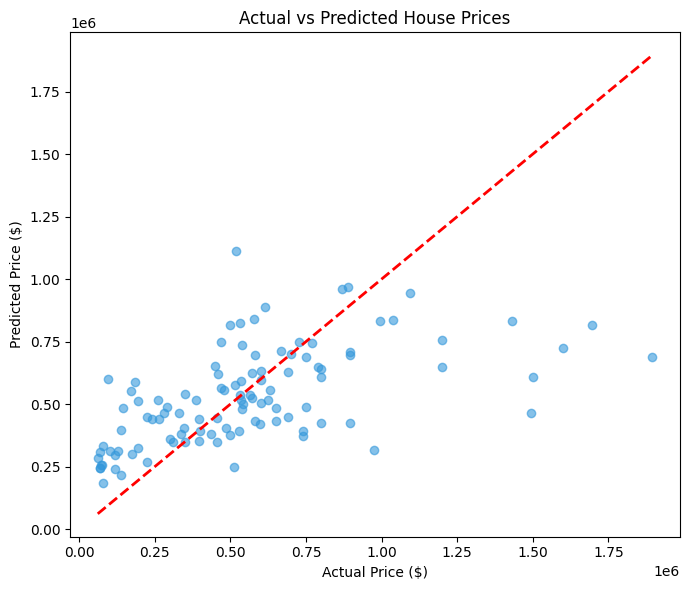

Model saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
# Cell 14 — Visualize predictions vs actual + save the model
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred_real, alpha=0.6, color='#3498db')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs Predicted House Prices')
plt.tight_layout()
plt.show()

# Save the trained model
model2.save('multimodal_housing_model.keras')
print("Model saved!")

from google.colab import files
files.download('multimodal_housing_model.keras')